## Results validation and info merging 

In [13]:
import pandas as pd

# --- CONFIGURATION DES NOMS DE FICHIERS ---
file_adj = 'Network Adjustment/Final_adjustment.csv' 
file_coords = 'Network Adjustment/FINAL_Data_for_GSadjust_BURRIS.csv'
output_file = 'Absolute_Gravity_Final.csv'

# --- CHARGEMENT DES DONNÉES ---
df_adj = pd.read_csv(file_adj)
df_adj.columns = [c.strip() for c in df_adj.columns]

df_raw = pd.read_csv(file_coords)
df_raw.columns = [c.strip() for c in df_raw.columns]

# --- ÉTAPE CRUCIALE : NETTOYAGE DU FICHIER D'AJUSTEMENT ---
# On supprime les coordonnées "tronquées" du fichier GSadjust pour ne pas avoir de doublons
cols_to_drop = ['Latitude', 'Longitude', 'Elevation']
df_adj_clean = df_adj.drop(columns=[c for c in cols_to_drop if c in df_adj.columns])

# --- PRÉPARATION DES COORDONNÉES PRÉCISES ---
# On récupère une seule ligne par station avec les valeurs exactes
df_coords_precise = df_raw.groupby('Station ID').agg({
    'Latitude': 'first',
    'Longitude': 'first',
    'Elevation': 'first',
    'Date': 'first'
}).reset_index()

# --- FUSION DES FICHIERS ---
# On fusionne le g calculé avec les coordonnées exactes
final_df = pd.merge(
    df_adj_clean, 
    df_coords_precise, 
    left_on='Station', 
    right_on='Station ID', 
    how='left'
)

# --- SÉLECTION DES COLONNES FINALES ---
# Change les noms '2024-04-02_g' et '2024-04-02_sd' si ta date d'ajustement est différente
cols_finales = [
    'Station', 
    'Latitude', 
    'Longitude', 
    'Elevation', 
    '2024-04-02_g', 
    '2024-04-02_sd', 
    'Date'
]

# On crée le fichier final propre
final_export = final_df[cols_finales].copy()

# Renommage pour le rapport final
final_export.columns = [
    'Station Name', 
    'Latitude', 
    'Longitude', 
    'Elevation (m)', 
    'Gravity (μGal)', 
    'Uncertainty (μGal)', 
    'Survey Date'
]

# --- SAUVEGARDE ---
final_export.to_csv(output_file, index=False)
final_export

,Station Name,Latitude,Longitude,Elevation (m),Gravity (μGal),Uncertainty (μGal),Survey Date
0,3RDB,28.234672,-16.629831,2224.2171,9.789625e+08,58.72,2024/04/02
1,CAMI1,28.330280,-16.532011,1627.8385,9.790837e+08,91.73,2024/07/31
2,CAMI2,28.331152,-16.523853,1717.3973,9.790640e+08,95.71,2024/07/31
3,CAMI3,28.336881,-16.505798,1818.4715,9.790384e+08,96.85,2024/07/31
4,CAMI4,28.327867,-16.510518,1957.0007,9.790108e+08,96.99,2024/07/31
...,...,...,...,...,...,...,...
90,ORO04,28.378930,-16.499700,798.3055,9.792580e+08,213.18,2024/10/13
91,ORO05,28.381335,-16.532591,463.0432,9.793288e+08,237.11,2024/10/13
92,ORO06,28.388417,-16.540545,335.4242,9.793544e+08,242.58,2024/10/13
93,ORO07,28.406020,-16.531432,214.1562,9.793800e+08,248.77,2024/10/13


--- GLOBAL NETWORK STATISTICS ---
      Metric  Gravity (μGal)  Uncertainty SD (µGal)
        Mean    9.790909e+08             144.840632
         Min    9.788918e+08               1.730000
         Max    9.793977e+08             298.170000
     Std Dev    1.583028e+05              74.296957
Median (50%)    9.790384e+08             115.790000


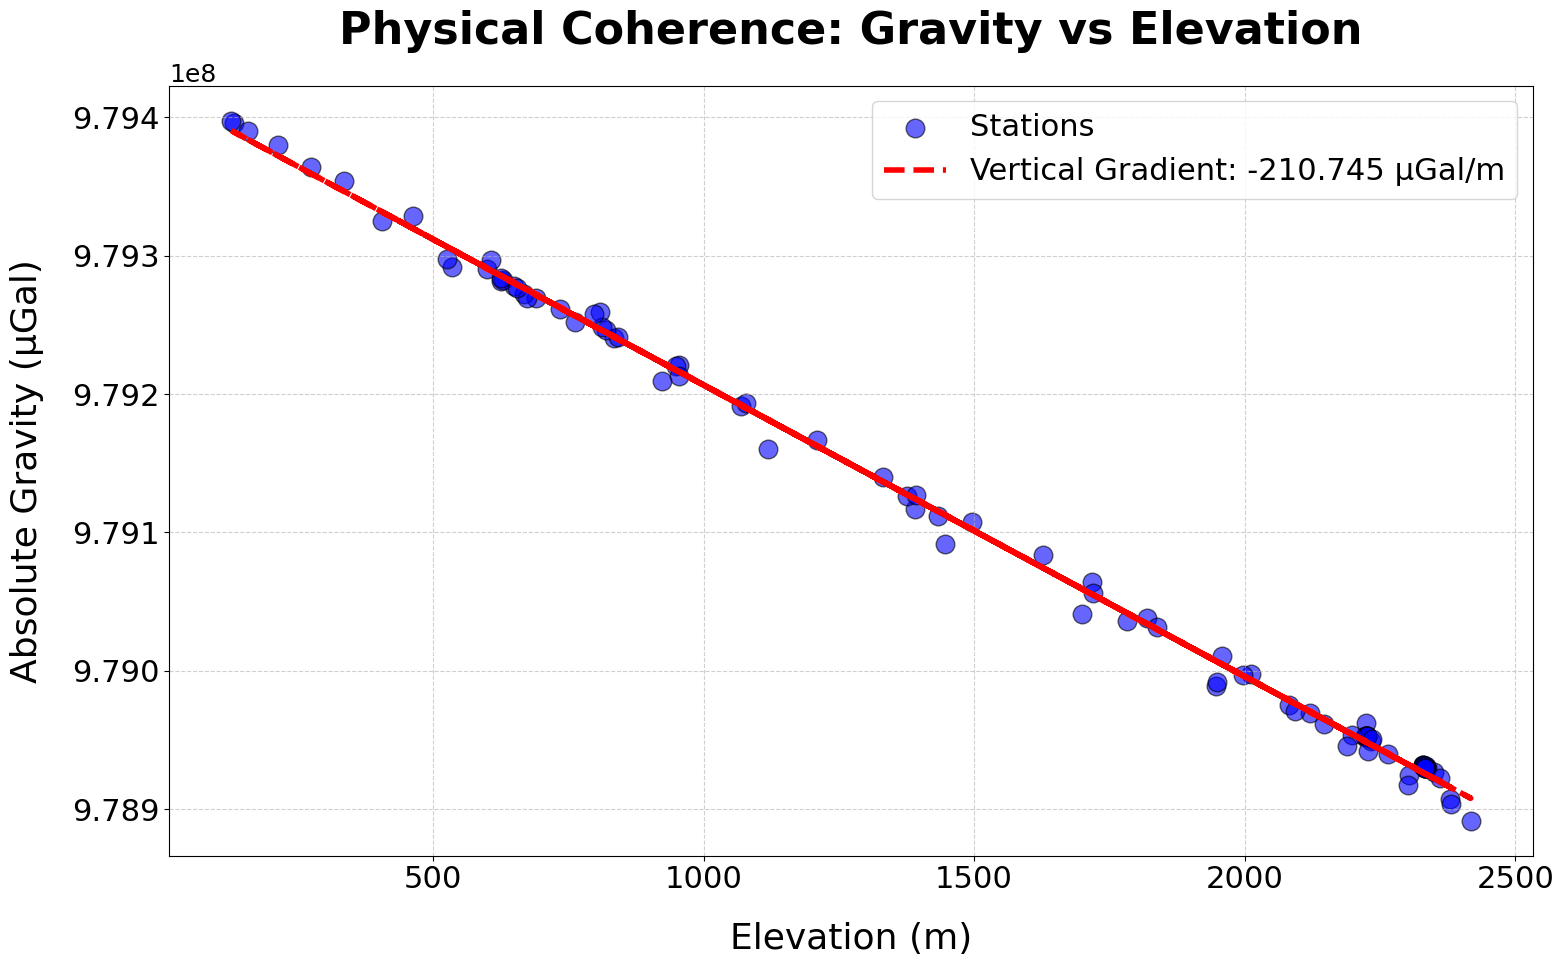

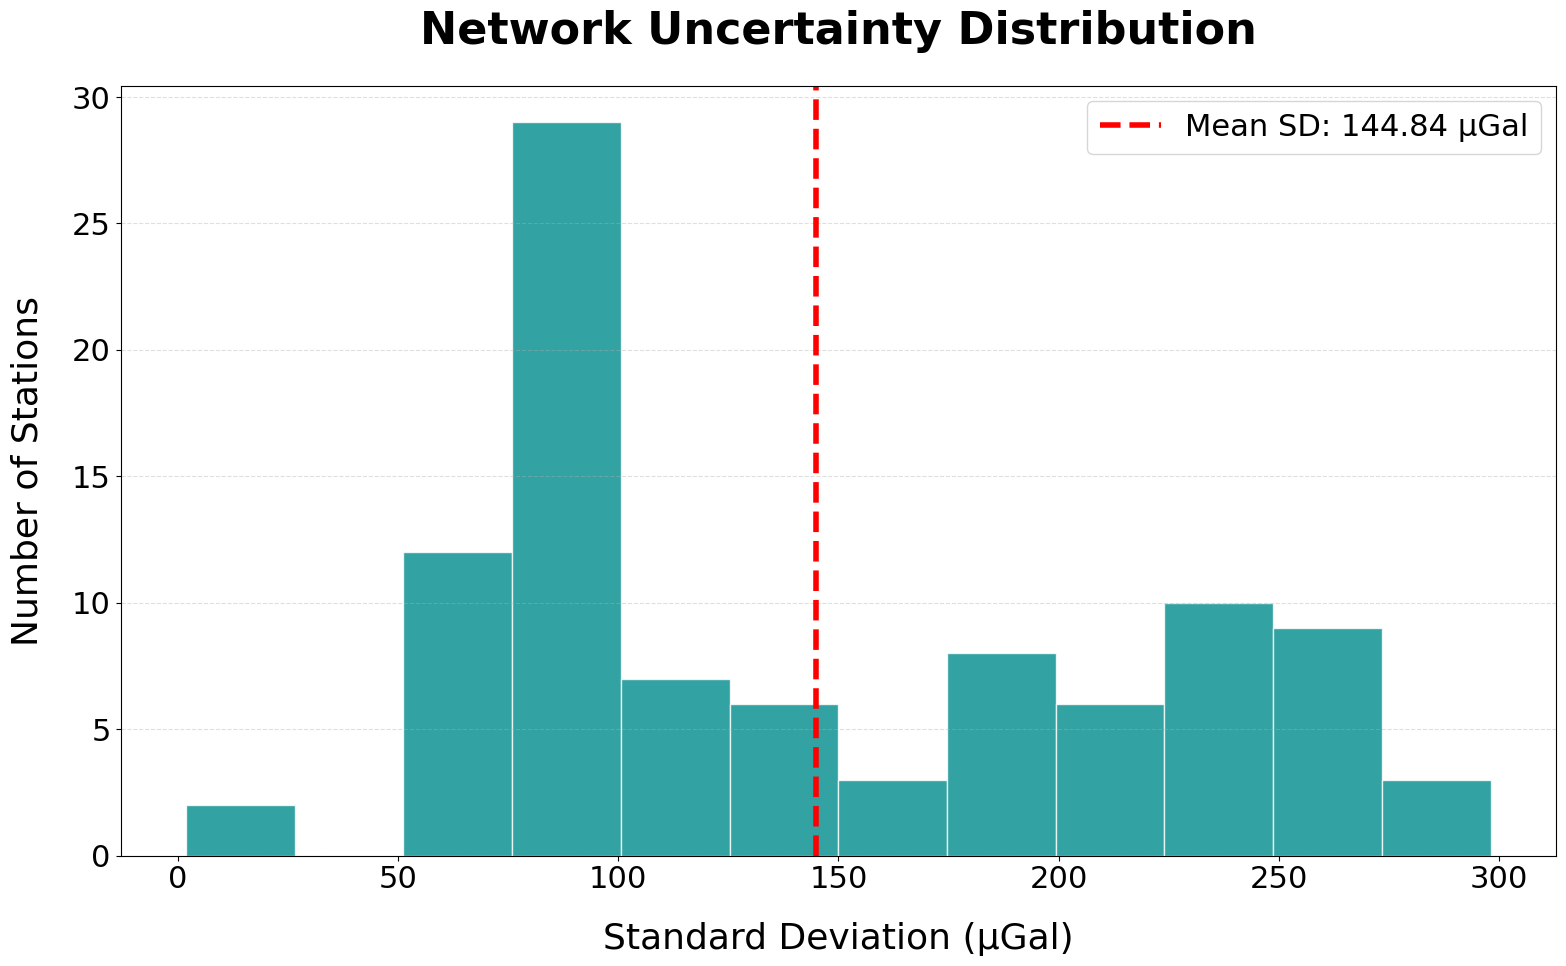

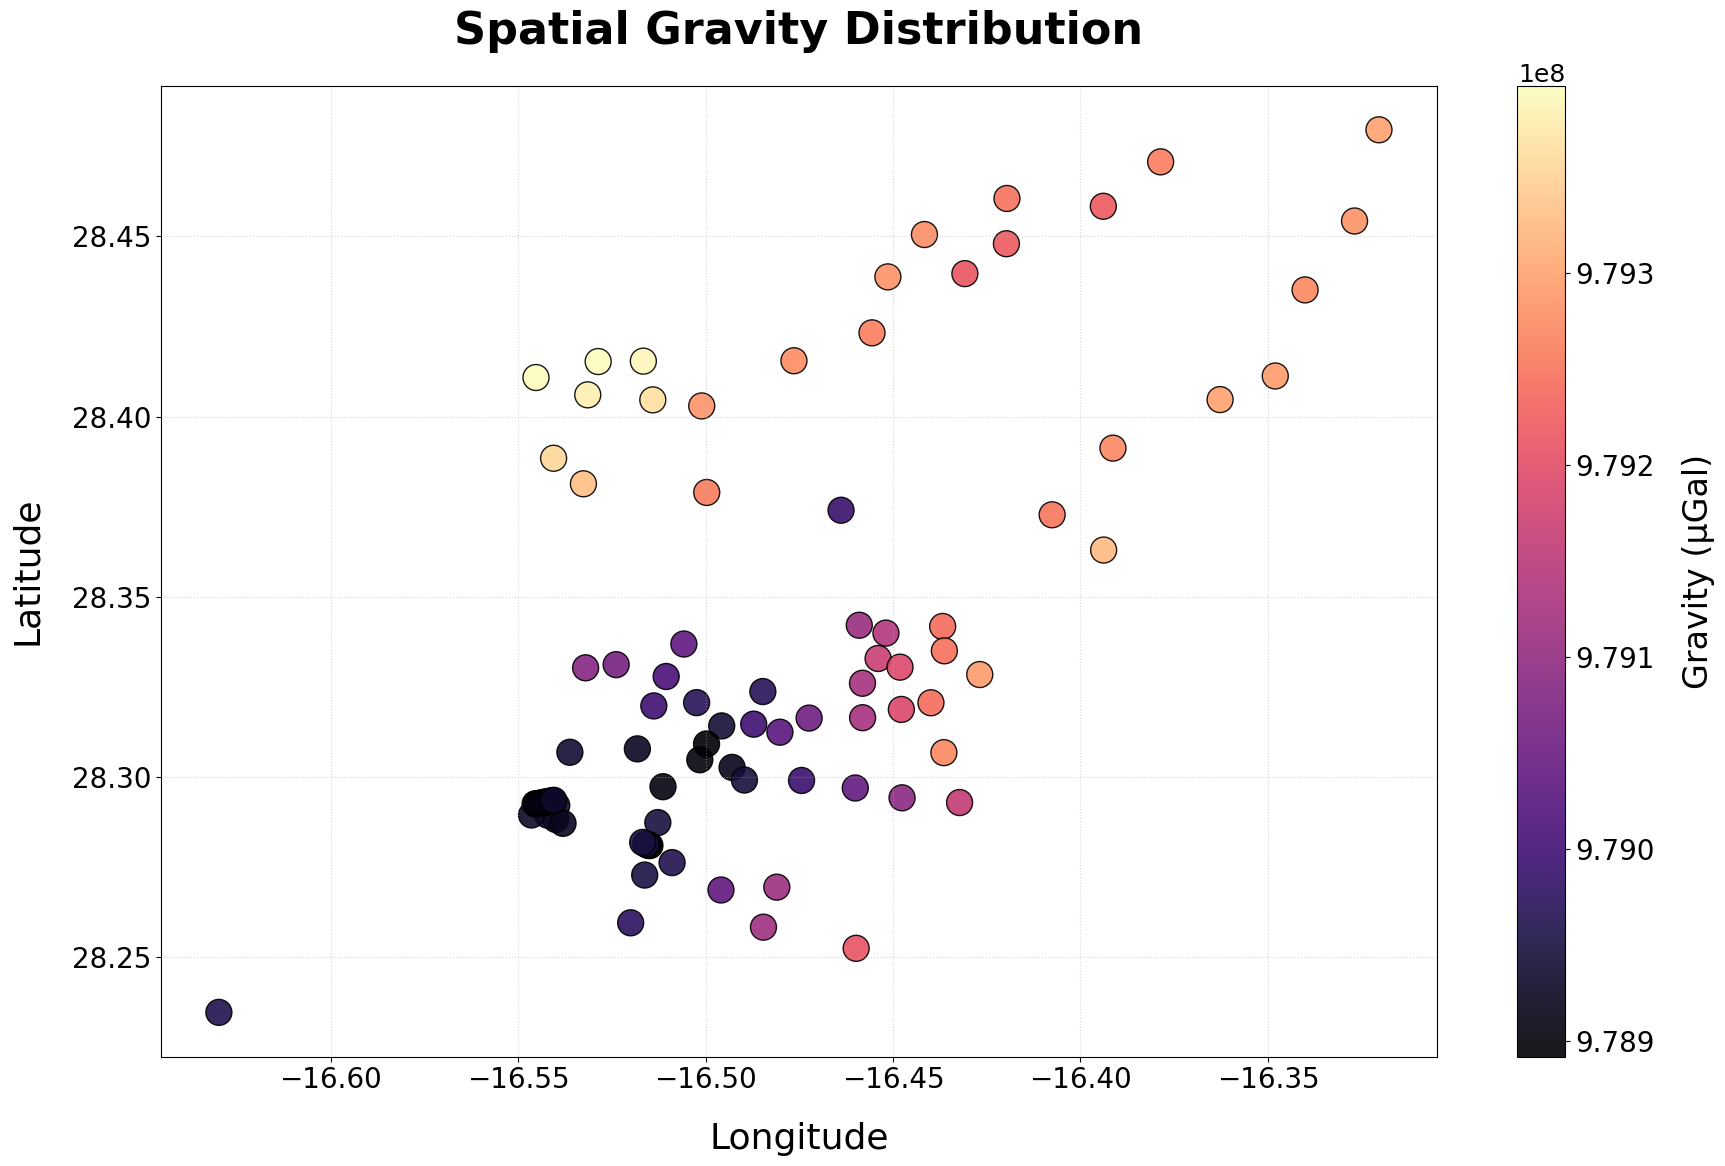

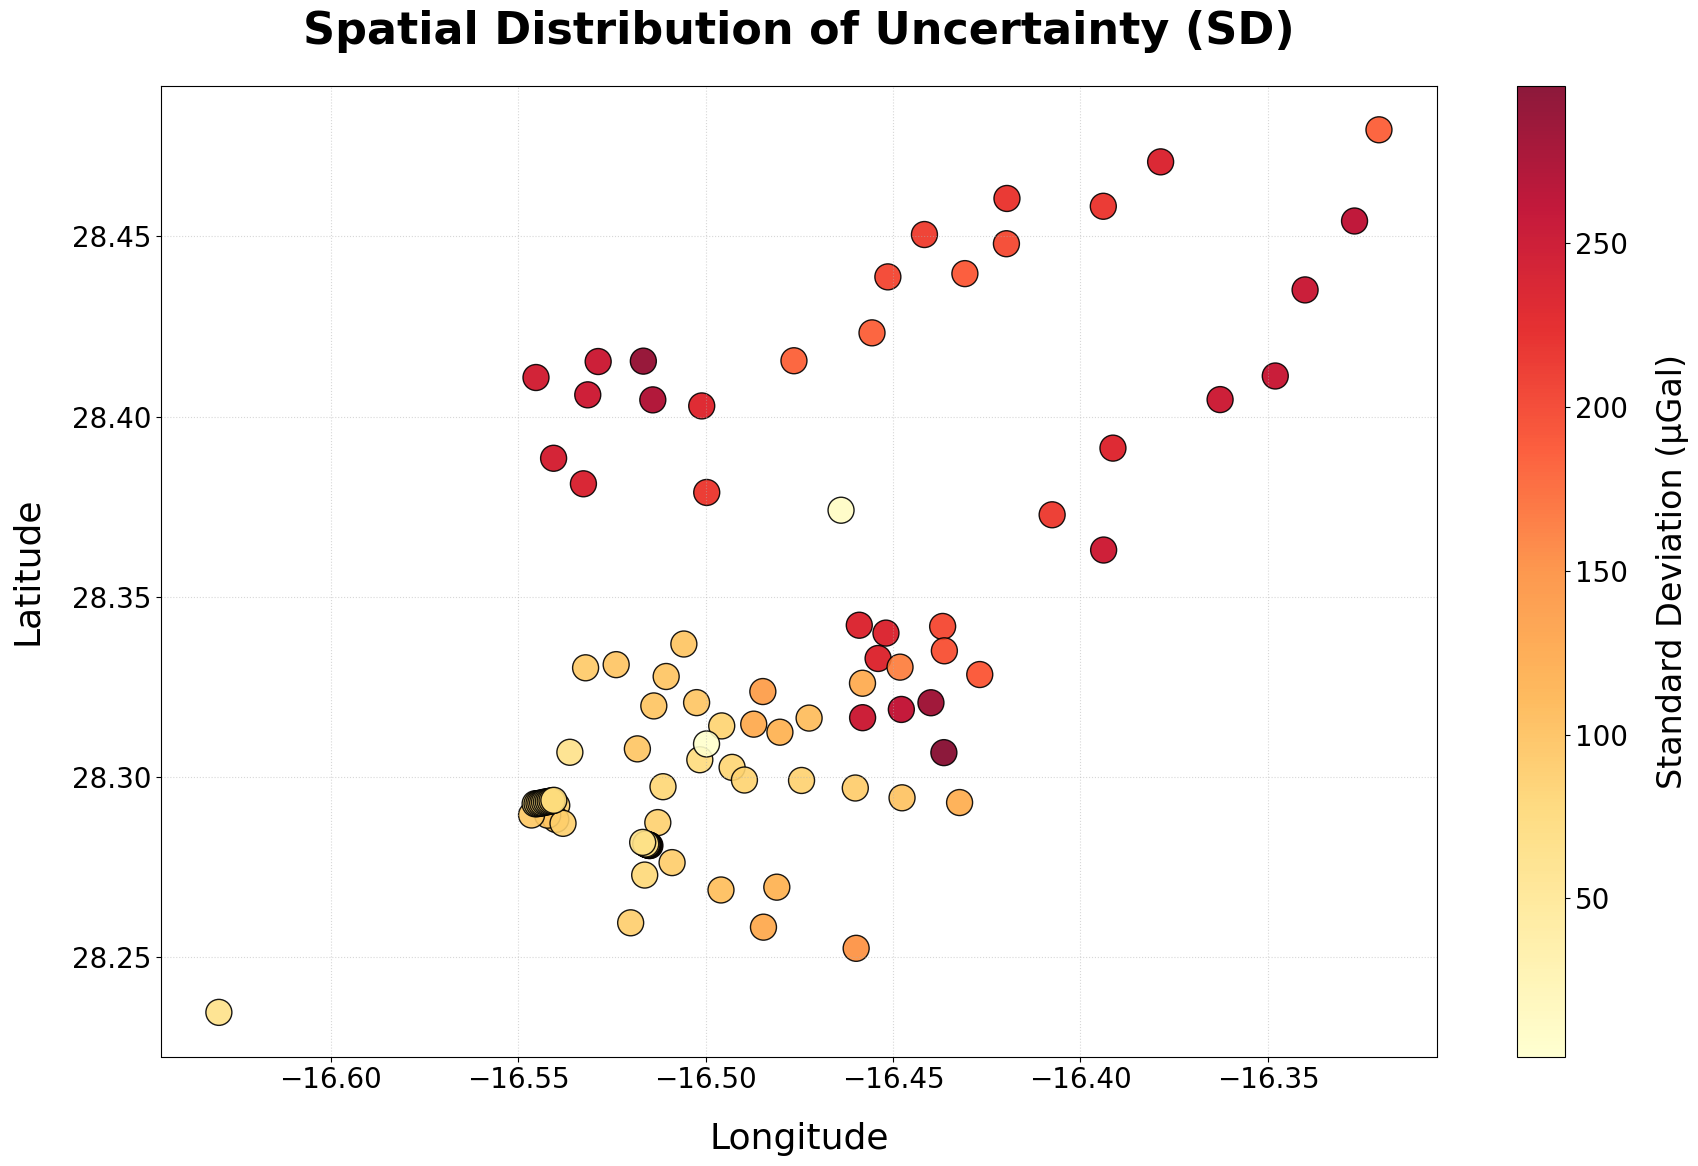

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Chargement des données
file_path = 'Absolute_Gravity_Final.csv'
df = pd.read_csv(file_path)

# Nettoyage des colonnes (supprime les espaces invisibles)
df.columns = [c.strip() for c in df.columns]

# Identification des colonnes
# Assure-toi que ces noms correspondent exactement à ton fichier CSV
grav_col = 'Gravity (μGal)'
sd_col = 'Uncertainty (μGal)'
elev_col = 'Elevation (m)'

# --- SECTION STATISTIQUES ---
print("--- GLOBAL NETWORK STATISTICS ---")
stats = pd.DataFrame({
    'Metric': ['Mean', 'Min', 'Max', 'Std Dev', 'Median (50%)'],
    'Gravity (μGal)': [
        df[grav_col].mean(), 
        df[grav_col].min(), 
        df[grav_col].max(), 
        df[grav_col].std(),
        df[grav_col].median()
    ],
    'Uncertainty SD (µGal)': [
        df[sd_col].mean(), 
        df[sd_col].min(), 
        df[sd_col].max(), 
        df[sd_col].std(),
        df[sd_col].median()
    ]
})
print(stats.to_string(index=False))

# --- GRAPHIQUE 1 : PHYSICAL COHERENCE (GRAVITY VS ELEVATION) ---
plt.figure(figsize=(16, 10))
plt.scatter(df[elev_col], df[grav_col], color='blue', s=180, alpha=0.6, edgecolors='black', label='Stations')

# Regression linéaire (Calcul du Gradient Vertical)
z = np.polyfit(df[elev_col], df[grav_col], 1)
p = np.poly1d(z)
plt.plot(df[elev_col], p(df[elev_col]), "r--", linewidth=4, label=f'Vertical Gradient: {z[0]:.3f} μGal/m')

plt.title('Physical Coherence: Gravity vs Elevation', fontsize=32, fontweight='bold', pad=30)
plt.xlabel('Elevation (m)', fontsize=26, labelpad=20)
plt.ylabel('Absolute Gravity (μGal)', fontsize=26, labelpad=20)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=22)
plt.tight_layout()
plt.savefig('FIG_gravity_vs_elevation.png')

# --- GRAPHIQUE 2 : UNCERTAINTY HISTOGRAM (µGAL) ---
plt.figure(figsize=(16, 10))
plt.hist(df[sd_col], bins=12, color='darkcyan', edgecolor='white', alpha=0.8)

mean_sd = df[sd_col].mean()
plt.axvline(mean_sd, color='red', linestyle='--', linewidth=4, label=f'Mean SD: {mean_sd:.2f} µGal')

plt.title('Network Uncertainty Distribution', fontsize=32, fontweight='bold', pad=30)
plt.xlabel('Standard Deviation (µGal)', fontsize=26, labelpad=20)
plt.ylabel('Number of Stations', fontsize=26, labelpad=20)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.legend(fontsize=22)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('FIG_uncertainty_histogram.png')

# --- GRAPHIQUE 3 : SPATIAL MAP OF GRAVITY ---
plt.figure(figsize=(18, 12))
sc1 = plt.scatter(df['Longitude'], df['Latitude'], c=df[grav_col], 
                  cmap='magma', s=350, edgecolor='black', alpha=0.9)

plt.title('Spatial Gravity Distribution', fontsize=32, fontweight='bold', pad=30)
plt.xlabel('Longitude', fontsize=26, labelpad=20)
plt.ylabel('Latitude', fontsize=26, labelpad=20)
plt.tick_params(axis='both', which='major', labelsize=20)

cbar1 = plt.colorbar(sc1)
cbar1.set_label('Gravity (μGal)', fontsize=24, labelpad=20)
cbar1.ax.tick_params(labelsize=20)

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('FIG_spatial_map_gravity.png')

# --- GRAPHIQUE 4 : SPATIAL MAP OF UNCERTAINTY (SD) ---
plt.figure(figsize=(18, 12))
# On utilise le colormap 'YlOrRd' (Jaune-Orange-Rouge) pour bien voir les zones "chaudes" (plus d'erreur)
sc2 = plt.scatter(df['Longitude'], df['Latitude'], c=df[sd_col], 
                  cmap='YlOrRd', s=350, edgecolor='black', alpha=0.9)

plt.title('Spatial Distribution of Uncertainty (SD)', fontsize=32, fontweight='bold', pad=30)
plt.xlabel('Longitude', fontsize=26, labelpad=20)
plt.ylabel('Latitude', fontsize=26, labelpad=20)
plt.tick_params(axis='both', which='major', labelsize=20)

cbar2 = plt.colorbar(sc2)
cbar2.set_label('Standard Deviation (µGal)', fontsize=24, labelpad=20)
cbar2.ax.tick_params(labelsize=20)

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('FIG_spatial_map_uncertainty.png')

plt.show()

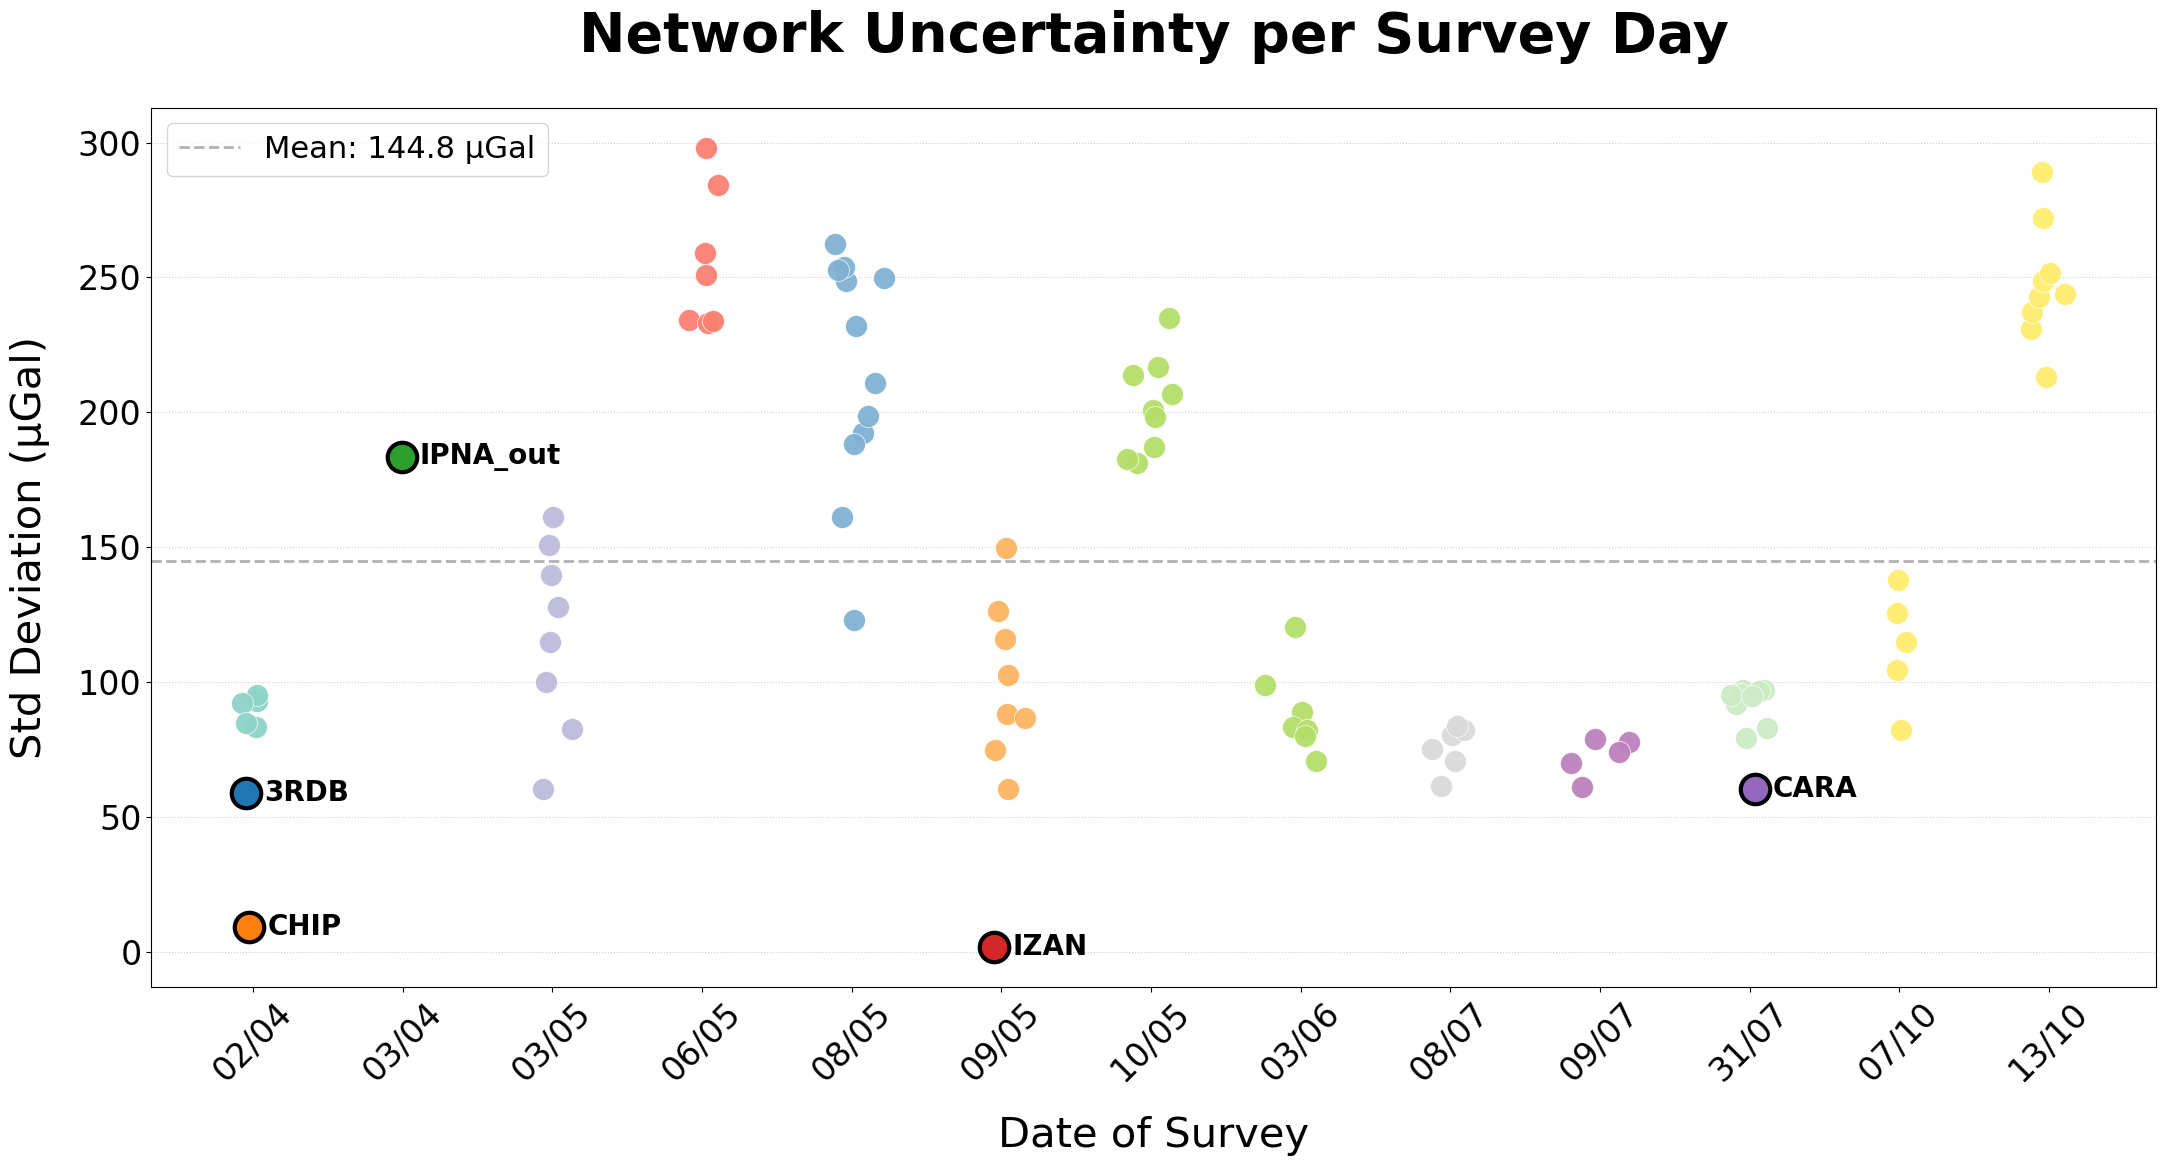

In [27]:
# --- VERSION FINALE : COULEURS PASTELS ET POLICE XL ---

import matplotlib.pyplot as plt
import numpy as np

# Liste des stations à mettre en avant
target_stations = ['CHIP', 'CARA', 'IZAN', 'IPNA_out', '3RDB']

# 1. Préparation des couleurs pastels
unique_dates = sorted(df['Survey Date'].unique())
# On utilise le colormap 'Set3' qui est parfait pour les tons pastels
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_dates)))

plt.figure(figsize=(22, 12))

# 2. Boucle par date
for i, date in enumerate(unique_dates):
    subset = df[df['Survey Date'] == date]
    x_jitter = np.random.normal(i, 0.08, size=len(subset))
    
    # Couleur du jour
    day_color = colors[i]
    
    # --- TOUS LES POINTS DU JOUR (PASTEL) ---
    plt.scatter(x_jitter, subset['Uncertainty (μGal)'], 
                s=250, # Points plus gros
                alpha=0.95, 
                color=day_color, 
                edgecolors='white', 
                linewidth=0.5,
                zorder=2)
    
    # --- STATIONS CIBLES (ROUGE VIF) ---
    for idx, row in subset.iterrows():
        s_name = str(row['Station Name']).strip()
        if s_name in target_stations:
            curr_x = x_jitter[subset.index.get_loc(idx)]
            
            # Point rouge plus gros (450)
            plt.scatter(curr_x, row['Uncertainty (μGal)'], 
                        #color='red', 
                        s=450, edgecolors='black', 
                        linewidth=3, zorder=5)
            
            # Label plus gros (20)
            plt.text(curr_x + 0.12, row['Uncertainty (μGal)'], s_name, 
                     fontsize=20, fontweight='bold', color='black',
                     verticalalignment='center',
                     #bbox=dict(facecolor='white', alpha=0.9, edgecolor='red', pad=3)
                    )

# --- RÉGLAGES POLICE XL ---
plt.title('Network Uncertainty per Survey Day', fontsize=40, fontweight='bold', pad=40)
plt.ylabel('Std Deviation (μGal)', fontsize=30, labelpad=20)
plt.xlabel('Date of Survey', fontsize=30, labelpad=20)

# Axe X : Dates plus grosses
plt.xticks(range(len(unique_dates)), [d.strftime('%d/%m') for d in unique_dates], 
           rotation=45, fontsize=24)
plt.tick_params(axis='y', labelsize=24)

# Ligne de moyenne
mean_val = df['Uncertainty (μGal)'].mean()
plt.axhline(mean_val, color='black', linestyle='--', alpha=0.3, linewidth=2,
            label=f"Mean: {mean_val:.1f} μGal")

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=22, loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('FIG_uncertainty_pastel_final.png', dpi=300)
plt.show()